<a href="https://colab.research.google.com/github/ervatoker/IOT-Erva-Toker/blob/main/ExcelFormer_TONIoT_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CONFIG

DRIVE_DATASET = "/content/drive/MyDrive/datasets/toniot_arnob_dataset"
DRIVE_OUT_DIR = "/content/drive/MyDrive/toniot_outputs"

LABEL_COL   = "type"
RANDOM_SEED = 42
TEST_SIZE   = 0.2
VAL_SIZE    = 0.1

# ExcelFormer settings
N_EPOCHS_EXCELFORMER = 200
EARLY_STOPPING       = 20
BATCH_SIZE           = 512
DEVICE               = "cuda"

print("Config loaded.")

Config loaded.


In [2]:
# INSTALL

!pip install -q pytorch-frame
!pip install -q scikit-learn pandas numpy matplotlib seaborn

print("All packages installed restart runtime if prompted")

All packages installed restart runtime if prompted


In [3]:
# IMPORTS + DRIVE + GPU CHECK

import os, glob, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix,
                             precision_score, recall_score,
                             roc_auc_score, cohen_kappa_score,
                             matthews_corrcoef, roc_curve, auc)

from google.colab import drive
drive.mount("/content/drive")
os.makedirs(DRIVE_OUT_DIR, exist_ok=True)

if not torch.cuda.is_available():
    raise RuntimeError(
        "\n\n NO GPU DETECTED!\n"
        "-> Go to Runtime -> Change runtime type\n"
        "-> Select T4 GPU\n"
        "-> Click Save\n"
        "-> Re-run from Cell 1\n"
    )

device = torch.device("cuda")
print(f"GPU confirmed : {torch.cuda.get_device_name(0)}")
print(f"VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Device        : {device}")

Mounted at /content/drive
GPU confirmed : Tesla T4
VRAM          : 15.6 GB
Device        : cuda


In [4]:
#LOAD DATA

csv_files = glob.glob(os.path.join(DRIVE_DATASET, "**/*.csv"), recursive=True)
print(f"Found {len(csv_files)} CSV files")

dfs = []
for f in csv_files:
    try:
        dfs.append(pd.read_csv(f, low_memory=False))
    except Exception as e:
        print(f"  Skipped {f}: {e}")

df = pd.concat(dfs, ignore_index=True)
print(f"Total rows: {len(df):,}  |  Columns: {df.shape[1]}")
print(f"\nLabel distribution:\n{df[LABEL_COL].value_counts()}")

Found 1 CSV files
Total rows: 211,043  |  Columns: 44

Label distribution:
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64


In [5]:
# PREPROCESS

# Drop label + non-feature columns
drop_cols = [LABEL_COL]
for col in ["ts", "src_ip", "dst_ip", "src_mac", "dst_mac"]:
    if col in df.columns:
        drop_cols.append(col)

X = df.drop(columns=drop_cols)
y_raw = df[LABEL_COL]

# Encode string labels to integers
le = LabelEncoder()
y = le.fit_transform(y_raw)
num_classes = len(le.classes_)
print(f"Classes ({num_classes}): {list(le.classes_)}")

# Keep numeric only + replace inf
X = X.select_dtypes(include=[np.number])
X = X.replace([np.inf, -np.inf], np.nan)
print(f"Features: {X.shape[1]}")

# Split FIRST before any imputation or scaling (70/10/20)
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=RANDOM_SEED,
    stratify=y_tv)

print(f"\nTrain : {len(X_train):,}")
print(f"Val   : {len(X_val):,}")
print(f"Test  : {len(X_test):,}")

# Impute NaN using TRAIN median only
train_median = X_train.median()
X_train = X_train.fillna(train_median)
X_val   = X_val.fillna(train_median)
X_test  = X_test.fillna(train_median)

# Scale using TRAIN statistics only
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

n_features = X_train_s.shape[1]
print(f"\nFeatures after preprocessing : {n_features}")
print(" Preprocessing complete — no data leakage")

Classes (10): ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']
Features: 17

Train : 147,729
Val   : 21,105
Test  : 42,209

Features after preprocessing : 17
 Preprocessing complete — no data leakage


In [6]:
# EVALUATION HELPER

all_results = []  # collect results from all models

def evaluate(model_name, y_true, y_pred, label_names, out_dir):
    acc        = accuracy_score(y_true, y_pred)
    f1_macro   = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n{'='*55}")
    print(f"  {model_name} — Results")
    print(f"{'='*55}")
    print(f"  Accuracy      : {acc:.4f}")
    print(f"  F1 (macro)    : {f1_macro:.4f}")
    print(f"  F1 (weighted) : {f1_weighted:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=label_names, zero_division=0)}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout()
    path = os.path.join(out_dir, f"{model_name.lower().replace(' ','_')}_cm.png")
    plt.savefig(path, dpi=150); plt.show()
    print(f"Saved: {path}")

    res = {"model": model_name, "accuracy": acc,
           "f1_macro": f1_macro, "f1_weighted": f1_weighted}
    all_results.append(res)
    return res

In [7]:
# ExcelFormer

import torch_frame
from torch_frame import stype, TensorFrame, Metric
from torch_frame.data import DataLoader as TFDataLoader
from torch_frame.nn import ExcelFormer
from torch_frame.transforms import MutualInformationSort
from torch_frame.data.stats import StatType
from torch.optim.lr_scheduler import ExponentialLR



col_names = [f"f{i}" for i in range(n_features)]

def make_tensor_frame(X_np, y_np):

    feat_dict = {
        stype.numerical: torch.tensor(X_np, dtype=torch.float32),
    }
    col_names_dict = {
        stype.numerical: col_names,
    }
    y_tensor = torch.tensor(y_np, dtype=torch.long)
    return TensorFrame(
        feat_dict=feat_dict,
        col_names_dict=col_names_dict,
        y=y_tensor,
    )

train_tf = make_tensor_frame(X_train_s, y_train)
val_tf   = make_tensor_frame(X_val_s,   y_val)
test_tf  = make_tensor_frame(X_test_s,  y_test)

# Compute col_stats from training data (needed by ExcelFormer)
col_stats = {}
for i, name in enumerate(col_names):
    col_vals = X_train_s[:, i]
    col_stats[name] = {
        StatType.MEAN: float(np.mean(col_vals)),
        StatType.STD: float(np.std(col_vals)),



    }

# MutualInformationSort (feature ordering by MI with target)
mi_sort = MutualInformationSort(task_type=torch_frame.TaskType.MULTICLASS_CLASSIFICATION)
mi_sort.fit(train_tf, col_stats)
train_tf = mi_sort(train_tf)
val_tf   = mi_sort(val_tf)
test_tf  = mi_sort(test_tf)

# DataLoaders
train_loader = TFDataLoader(train_tf, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = TFDataLoader(val_tf,   batch_size=BATCH_SIZE)
test_loader  = TFDataLoader(test_tf,  batch_size=BATCH_SIZE)

# Build ExcelFormer model
ef_model = ExcelFormer(
    in_channels=256,
    out_channels=num_classes,
    num_cols=train_tf.num_cols,
    num_layers=5,
    num_heads=4,
    residual_dropout=0.0,
    diam_dropout=0.3,
    aium_dropout=0.0,
    mixup='feature',
    col_stats=mi_sort.transformed_stats,
    col_names_dict=train_tf.col_names_dict,
).to(device)

optimizer = torch.optim.Adam(ef_model.parameters(), lr=1e-3)
lr_scheduler = ExponentialLR(optimizer, gamma=0.95)

print(f"ExcelFormer params : {sum(p.numel() for p in ef_model.parameters()):,}")
print(f"Device             : {device}")
print(f"Max epochs         : {N_EPOCHS_EXCELFORMER}")
print(f"Early stop         : {EARLY_STOPPING} epochs patience")
print("Training ExcelFormer...")

t0 = time.time()
best_val_f1      = 0
best_state       = None
ef_history        = []
no_improve_count = 0

for epoch in range(1, N_EPOCHS_EXCELFORMER + 1):
    #Train with mixup
    ef_model.train()
    for tf_batch in train_loader:
        tf_batch = tf_batch.to(device)
        pred_mixed, y_mixed = ef_model(tf_batch, mixup_encoded=True)
        loss = F.cross_entropy(pred_mixed, y_mixed)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Validate
    ef_model.eval()
    preds_all, true_all = [], []
    with torch.no_grad():
        for tf_batch in val_loader:
            tf_batch = tf_batch.to(device)
            pred = ef_model(tf_batch)
            preds_all.extend(pred.argmax(dim=-1).cpu().numpy())
            true_all.extend(tf_batch.y.cpu().numpy())

    val_f1  = f1_score(true_all, preds_all, average="macro", zero_division=0)
    val_acc = accuracy_score(true_all, preds_all)
    ef_history.append({"epoch": epoch, "val_f1": val_f1, "val_acc": val_acc})

    print(f"  Epoch {epoch:03d}/{N_EPOCHS_EXCELFORMER} | "
          f"Val Acc: {val_acc:.4f} | "
          f"Val F1: {val_f1:.4f} | "
          f"No improve: {no_improve_count}/{EARLY_STOPPING}")

    if val_f1 > best_val_f1:
        best_val_f1      = val_f1
        best_state       = {k: v.cpu() for k, v in ef_model.state_dict().items()}
        no_improve_count = 0
        print(f"   New best F1: {best_val_f1:.4f} — model saved")
    else:
        no_improve_count += 1
        if no_improve_count >= EARLY_STOPPING:
            print(f"\n Early stopping at epoch {epoch} "
                  f"— no improvement for {EARLY_STOPPING} epochs")
            break

    lr_scheduler.step()

ef_time = time.time() - t0
print(f"\nBest Val F1 (ExcelFormer): {best_val_f1:.4f} | Time: {ef_time:.1f}s")

ExcelFormer params : 1,996,726
Device             : cuda
Max epochs         : 200
Early stop         : 20 epochs patience
Training ExcelFormer...
  Epoch 001/200 | Val Acc: 0.8128 | Val F1: 0.7056 | No improve: 0/20
   New best F1: 0.7056 — model saved
  Epoch 002/200 | Val Acc: 0.8597 | Val F1: 0.7564 | No improve: 0/20
   New best F1: 0.7564 — model saved
  Epoch 003/200 | Val Acc: 0.9224 | Val F1: 0.8357 | No improve: 0/20
   New best F1: 0.8357 — model saved
  Epoch 004/200 | Val Acc: 0.9324 | Val F1: 0.8582 | No improve: 0/20
   New best F1: 0.8582 — model saved
  Epoch 005/200 | Val Acc: 0.9357 | Val F1: 0.8600 | No improve: 0/20
   New best F1: 0.8600 — model saved
  Epoch 006/200 | Val Acc: 0.9425 | Val F1: 0.8814 | No improve: 0/20
   New best F1: 0.8814 — model saved
  Epoch 007/200 | Val Acc: 0.9220 | Val F1: 0.8623 | No improve: 0/20
  Epoch 008/200 | Val Acc: 0.9472 | Val F1: 0.8926 | No improve: 1/20
   New best F1: 0.8926 — model saved
  Epoch 009/200 | Val Acc: 0.9389 |


  ExcelFormer — Results
  Accuracy      : 0.9851
  F1 (macro)    : 0.9592
  F1 (weighted) : 0.9853

              precision    recall  f1-score   support

    backdoor       1.00      1.00      1.00      4000
        ddos       0.99      0.97      0.98      4000
         dos       0.99      0.97      0.98      4000
   injection       0.98      0.95      0.96      4000
        mitm       0.66      0.82      0.73       209
      normal       1.00      1.00      1.00     10000
    password       0.99      0.99      0.99      4000
  ransomware       0.99      1.00      1.00      4000
    scanning       0.98      0.99      0.99      4000
         xss       0.95      0.98      0.97      4000

    accuracy                           0.99     42209
   macro avg       0.95      0.97      0.96     42209
weighted avg       0.99      0.99      0.99     42209



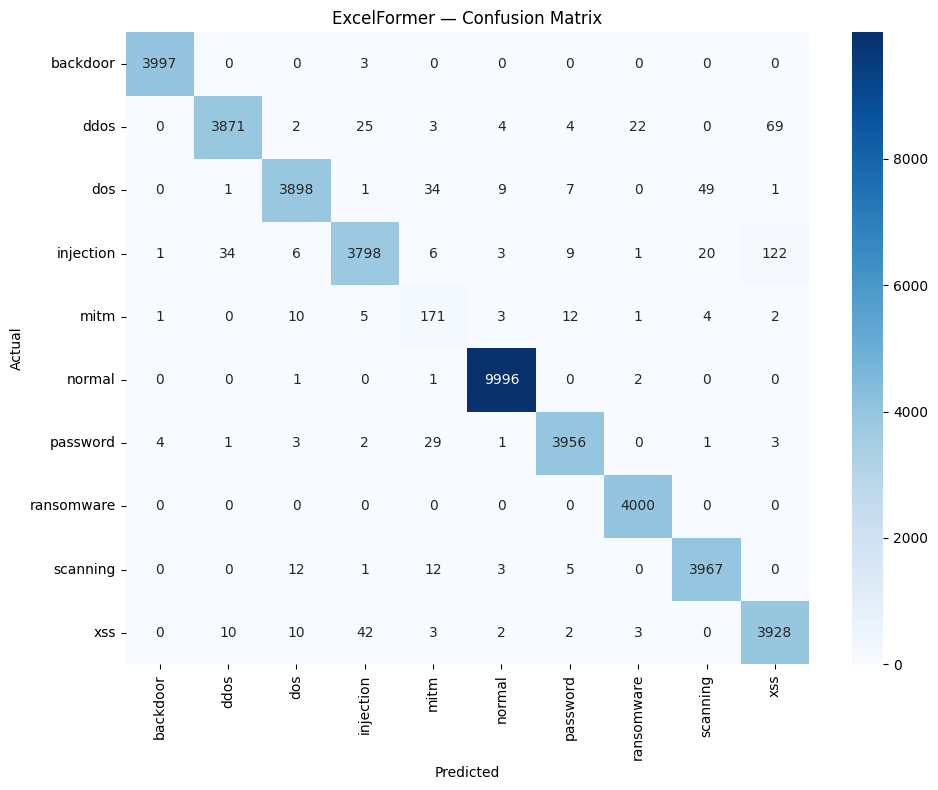

Saved: /content/drive/MyDrive/toniot_outputs/excelformer_cm.png


In [8]:
# ExcelFormer TEST EVALUATION

ef_model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
ef_model.eval()

all_preds, all_true, all_proba = [], [], []
with torch.no_grad():
    for tf_batch in test_loader:
        tf_batch = tf_batch.to(device)
        logits = ef_model(tf_batch)
        proba  = F.softmax(logits, dim=-1).cpu().numpy()
        preds  = logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(tf_batch.y.cpu().numpy())
        all_proba.append(proba)

ef_preds = np.array(all_preds)
ef_proba = np.concatenate(all_proba, axis=0)

ef_results = evaluate(
    "ExcelFormer", all_true, ef_preds,
    label_names=list(le.classes_),
    out_dir=DRIVE_OUT_DIR
)

  TABLE 1: ExcelFormer — Overall Evaluation Metrics
           Metric  Score
         Accuracy 0.9851
Precision (macro) 0.9530
   Recall (macro) 0.9672
       F1 (macro) 0.9592
    F1 (weighted) 0.9853
              MCC 0.9830
    Cohen's Kappa 0.9830
  ROC-AUC (macro) 0.9996



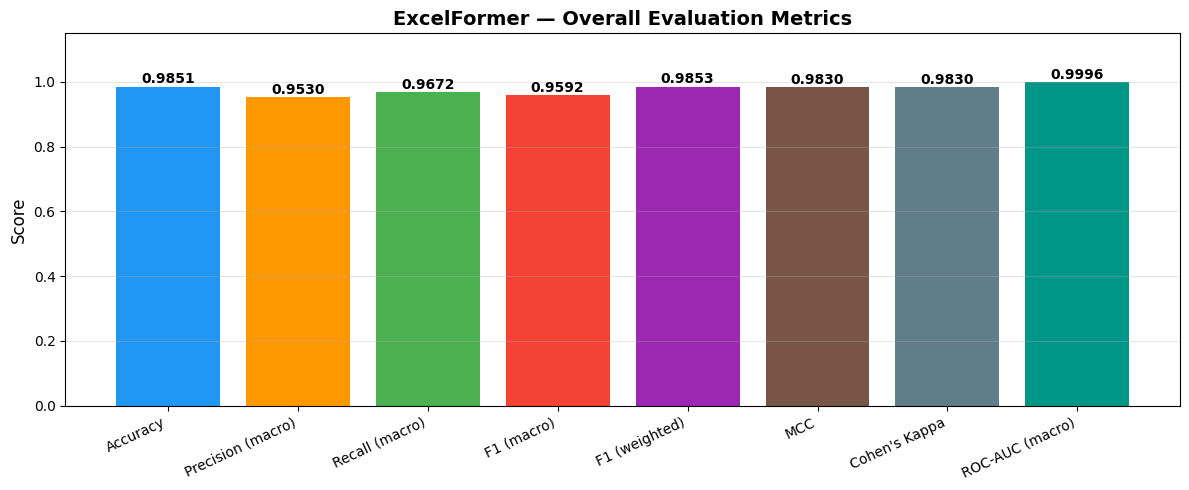

  TABLE 2: ExcelFormer — Per-Class Precision / Recall / F1
     Class  Precision  Recall  F1-Score  Support
  backdoor     0.9985  0.9992    0.9989     4000
      ddos     0.9883  0.9678    0.9779     4000
       dos     0.9888  0.9745    0.9816     4000
 injection     0.9796  0.9495    0.9643     4000
      mitm     0.6602  0.8182    0.7308      209
    normal     0.9975  0.9996    0.9986    10000
  password     0.9902  0.9890    0.9896     4000
ransomware     0.9928  1.0000    0.9964     4000
  scanning     0.9817  0.9918    0.9867     4000
       xss     0.9522  0.9820    0.9669     4000



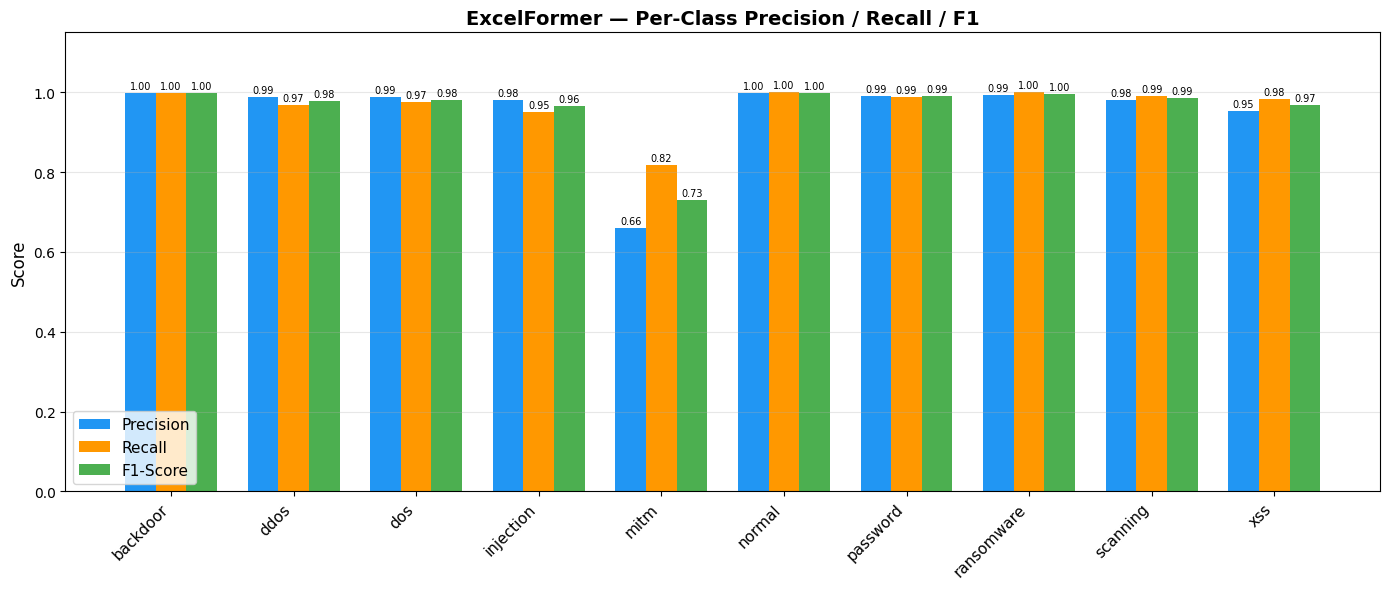

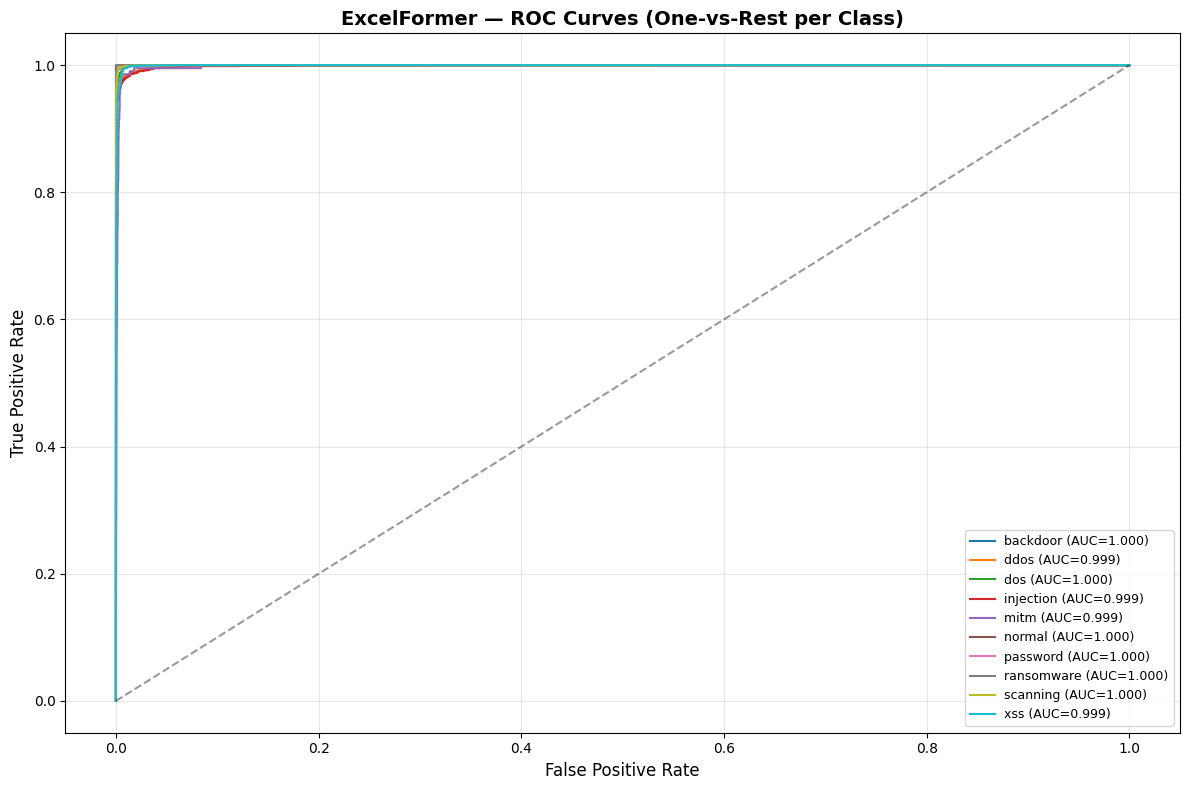

  TABLE 3: ExcelFormer — Per-Class ROC-AUC
     Class  ROC-AUC
  backdoor   1.0000
      ddos   0.9992
       dos   0.9999
 injection   0.9990
      mitm   0.9985
    normal   1.0000
  password   0.9999
ransomware   0.9999
  scanning   0.9999
       xss   0.9995

  Macro-average ROC-AUC: 0.9996

  TABLE 4: ExcelFormer — MCC & Cohen's Kappa
  MCC          : 0.9830 (Excellent)
  Cohen's Kappa: 0.9830 (Almost Perfect)


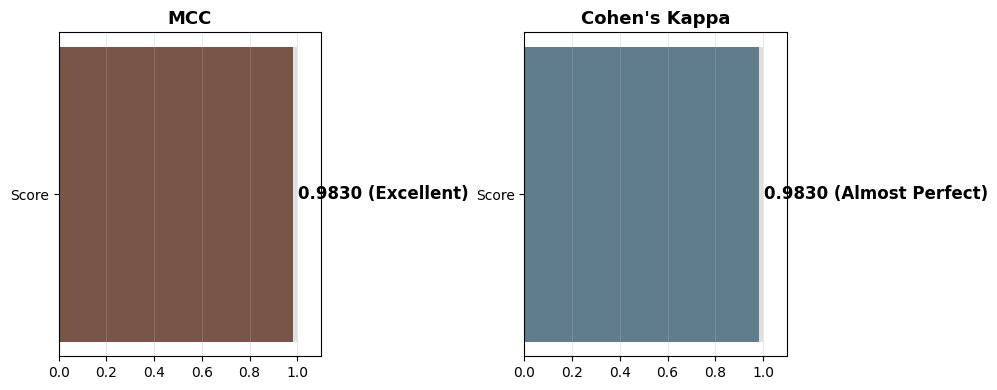

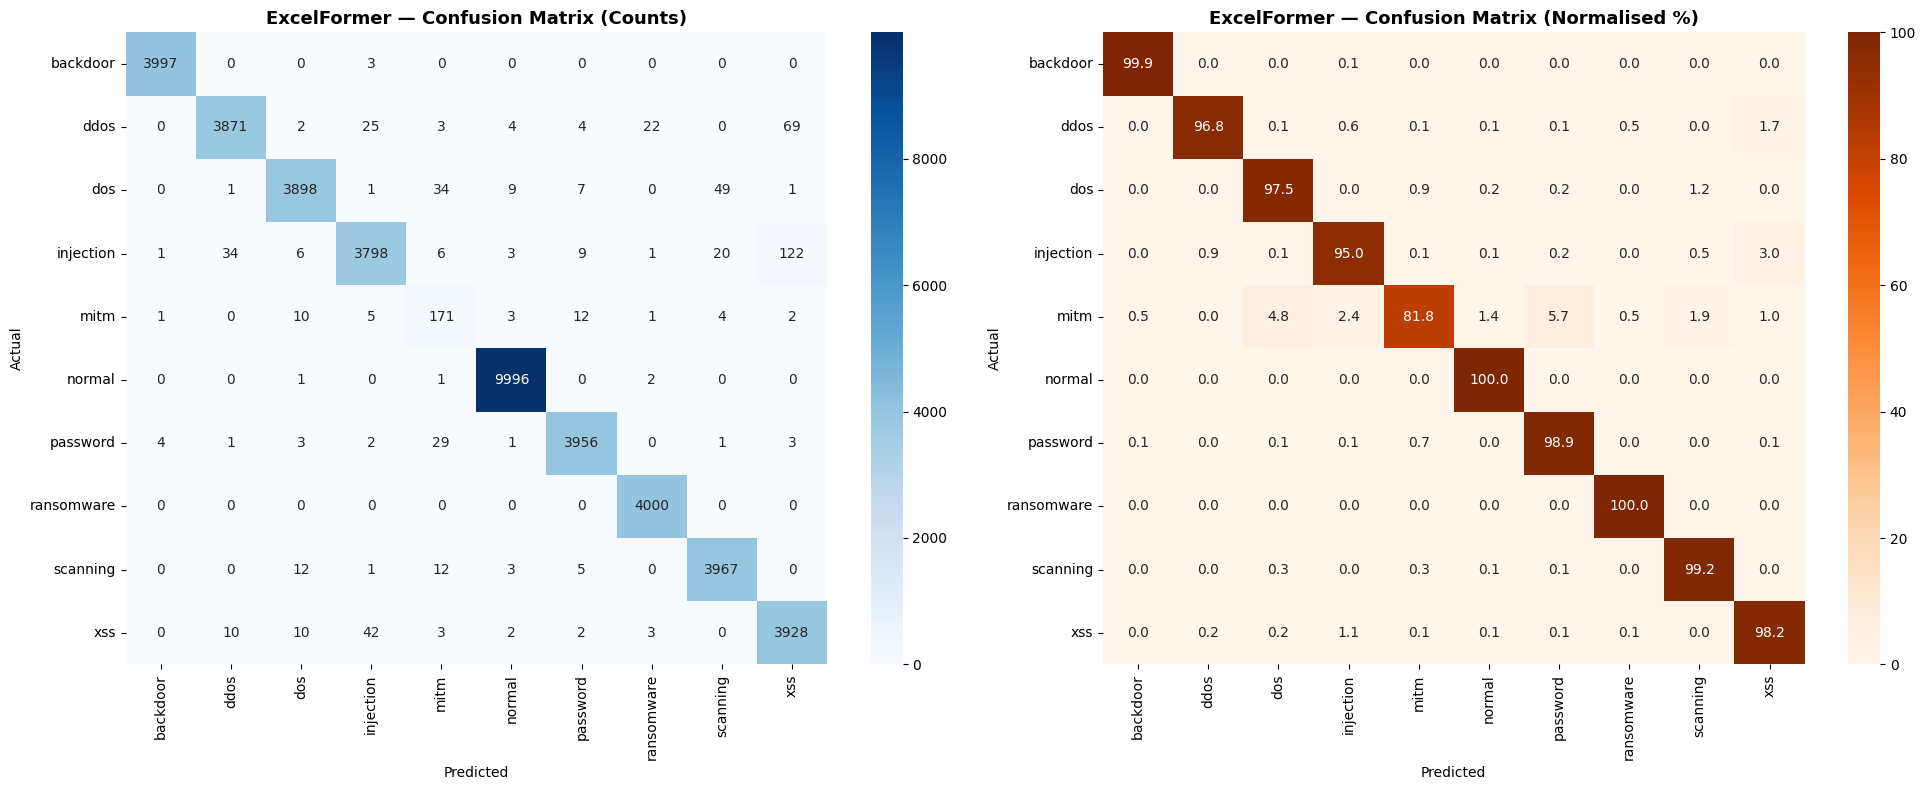


All visualisations saved to: /content/drive/MyDrive/toniot_outputs


In [9]:
# ExcelFormer TABLES & VISUALISATIONS

y_true = y_test
y_pred = ef_preds
y_prob = ef_proba
label_names = list(le.classes_)


# 1. MACRO METRICS SUMMARY TABLE + BAR CHART


acc         = accuracy_score(y_true, y_pred)
prec_macro  = precision_score(y_true, y_pred, average="macro", zero_division=0)
rec_macro   = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro    = f1_score(y_true, y_pred, average="macro", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
mcc         = matthews_corrcoef(y_true, y_pred)
kappa       = cohen_kappa_score(y_true, y_pred)

try:
    roc_auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
except:
    roc_auc = None

macro_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (macro)", "Recall (macro)",
               "F1 (macro)", "F1 (weighted)", "MCC", "Cohen's Kappa",
               "ROC-AUC (macro)"],
    "Score": [acc, prec_macro, rec_macro, f1_macro, f1_weighted,
              mcc, kappa, roc_auc if roc_auc else float('nan')]
})
macro_df["Score"] = macro_df["Score"].round(4)

print("=" * 60)
print("  TABLE 1: ExcelFormer — Overall Evaluation Metrics")
print("=" * 60)
print(macro_df.to_string(index=False))
print()

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#2196F3", "#FF9800", "#4CAF50", "#F44336", "#9C27B0", "#795548", "#607D8B", "#009688"]
valid = macro_df.dropna()
bars = ax.bar(valid["Metric"], valid["Score"], color=colors[:len(valid)])
for bar, val in zip(bars, valid["Score"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylim(0, 1.15); ax.set_ylabel("Score", fontsize=12)
ax.set_title("ExcelFormer — Overall Evaluation Metrics", fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.3); plt.xticks(rotation=25, ha="right"); plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "excelformer_macro_metrics.png"), dpi=150); plt.show()


# 2. PER-CLASS PRECISION, RECALL, F1 TABLE + CHART


prec_per = precision_score(y_true, y_pred, average=None, zero_division=0)
rec_per  = recall_score(y_true, y_pred, average=None, zero_division=0)
f1_per   = f1_score(y_true, y_pred, average=None, zero_division=0)

perclass_df = pd.DataFrame({
    "Class": label_names, "Precision": np.round(prec_per, 4),
    "Recall": np.round(rec_per, 4), "F1-Score": np.round(f1_per, 4),
    "Support": [np.sum(y_true == c) for c in range(num_classes)]
})
print("=" * 60)
print("  TABLE 2: ExcelFormer — Per-Class Precision / Recall / F1")
print("=" * 60)
print(perclass_df.to_string(index=False)); print()

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(label_names)); w = 0.25
b1 = ax.bar(x - w, prec_per, w, label="Precision", color="#2196F3")
b2 = ax.bar(x,     rec_per,  w, label="Recall",    color="#FF9800")
b3 = ax.bar(x + w, f1_per,   w, label="F1-Score",  color="#4CAF50")
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.01: ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.2f}", ha="center", fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(label_names, rotation=45, ha="right", fontsize=11)
ax.set_ylim(0, 1.15); ax.set_ylabel("Score", fontsize=12)
ax.set_title("ExcelFormer — Per-Class Precision / Recall / F1", fontsize=14, fontweight="bold")
ax.legend(fontsize=11); ax.grid(axis="y", alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "excelformer_perclass_prf.png"), dpi=150); plt.show()


# 3. ROC-AUC PER CLASS — TABLE + CURVES


y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
auc_per_class = []
fig, ax = plt.subplots(figsize=(12, 8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    class_auc = auc(fpr, tpr)
    auc_per_class.append(class_auc)
    ax.plot(fpr, tpr, label=f"{label_names[i]} (AUC={class_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate", fontsize=12); ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ExcelFormer — ROC Curves (One-vs-Rest per Class)", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9); ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "excelformer_roc_curves.png"), dpi=150); plt.show()

roc_df = pd.DataFrame({"Class": label_names, "ROC-AUC": np.round(auc_per_class, 4)})
print("=" * 60)
print("  TABLE 3: ExcelFormer — Per-Class ROC-AUC")
print("=" * 60)
print(roc_df.to_string(index=False))
if roc_auc: print(f"\n  Macro-average ROC-AUC: {roc_auc:.4f}")


# 4. MCC & COHEN'S KAPPA


def interpret_mcc(v):
    if v >= 0.9: return "Excellent"
    if v >= 0.7: return "Strong"
    if v >= 0.5: return "Moderate"
    if v >= 0.3: return "Weak"
    return "Poor"
def interpret_kappa(v):
    if v >= 0.81: return "Almost Perfect"
    if v >= 0.61: return "Substantial"
    if v >= 0.41: return "Moderate"
    if v >= 0.21: return "Fair"
    return "Slight/Poor"

print(); print("=" * 60)
print("  TABLE 4: ExcelFormer — MCC & Cohen's Kappa")
print("=" * 60)
print(f"  MCC          : {mcc:.4f} ({interpret_mcc(mcc)})")
print(f"  Cohen's Kappa: {kappa:.4f} ({interpret_kappa(kappa)})")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, mn, val, interp, col in [
    (axes[0], "MCC", mcc, interpret_mcc(mcc), "#795548"),
    (axes[1], "Cohen's Kappa", kappa, interpret_kappa(kappa), "#607D8B")]:
    ax.barh(["Score"], [val], color=col, height=0.4)
    ax.barh(["Score"], [1.0], color="#E0E0E0", height=0.4, zorder=0)
    ax.set_xlim(0, 1.1)
    ax.text(val + 0.02, 0, f"{val:.4f} ({interp})", va="center", fontsize=12, fontweight="bold")
    ax.set_title(mn, fontsize=13, fontweight="bold"); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "excelformer_mcc_kappa.png"), dpi=150); plt.show()


# 5. DUAL CONFUSION MATRIX


cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names, ax=axes[0])
axes[0].set_title("ExcelFormer — Confusion Matrix (Counts)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
sns.heatmap(cm_norm, annot=True, fmt=".1f", cmap="Oranges", xticklabels=label_names, yticklabels=label_names, ax=axes[1])
axes[1].set_title("ExcelFormer — Confusion Matrix (Normalised %)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "excelformer_cm_dual.png"), dpi=150); plt.show()

print("\nAll visualisations saved to:", DRIVE_OUT_DIR)

In [10]:
# OVERFITTING / UNDERFITTING DIAGNOSIS

ef_model.eval()
ef_train_preds = []
with torch.no_grad():
    for tf_batch in TFDataLoader(train_tf, batch_size=BATCH_SIZE):
        tf_batch = tf_batch.to(device)
        pred = ef_model(tf_batch)
        ef_train_preds.extend(pred.argmax(dim=-1).cpu().numpy())

ef_train_acc = accuracy_score(y_train, ef_train_preds)
ef_train_f1  = f1_score(y_train, ef_train_preds, average="macro", zero_division=0)

print("=" * 50)
print("ExcelFormer — Train vs Test Diagnosis")
print("=" * 50)
print(f"  Train Acc    : {ef_train_acc:.4f}")
print(f"  Test  Acc    : {ef_results['accuracy']:.4f}")
print(f"  Train F1     : {ef_train_f1:.4f}")
print(f"  Test  F1     : {ef_results['f1_macro']:.4f}")
print()

acc_gap = ef_train_acc - ef_results['accuracy']
if acc_gap > 0.05:
    print(f"  Warning: Generalisation gap: {acc_gap:.4f} — possible overfitting")
elif ef_results['accuracy'] < 0.80:
    print("  Warning: Low test accuracy — possible underfitting")
else:
    print(f"  Generalisation gap: {acc_gap:.4f} — model generalises well")

print(f"\n  Training time : {ef_time:.1f}s")

ExcelFormer — Train vs Test Diagnosis
  Train Acc    : 0.9876
  Test  Acc    : 0.9851
  Train F1     : 0.9692
  Test  F1     : 0.9592

  Generalisation gap: 0.0024 — model generalises well

  Training time : 1903.7s


In [11]:
# SAVE RESULTS

results_df = pd.DataFrame([{
    "model"           : "ExcelFormer",
    "paper"           : "KDD 2024 — Chen et al.",
    "dataset"         : "TON-IoT Network",
    "train_samples"   : len(X_train),
    "test_samples"    : len(X_test),
    "n_features"      : n_features,
    "n_classes"       : num_classes,
    "accuracy"        : acc,
    "f1_macro"        : f1_macro,
    "f1_weighted"     : f1_weighted,
    "precision_macro" : prec_macro,
    "recall_macro"    : rec_macro,
    "mcc"             : mcc,
    "cohen_kappa"     : kappa,
    "roc_auc_macro"   : roc_auc,
    "train_acc"       : ef_train_acc,
    "train_f1"        : ef_train_f1,
    "train_time_s"    : round(ef_time, 2),
}])

csv_path = os.path.join(DRIVE_OUT_DIR, "excelformer_toniot_results.csv")
results_df.to_csv(csv_path, index=False)

print("\n========== FINAL RESULTS ==========")
print(results_df.T.to_string())
print(f"\nResults saved to: {csv_path}")


========== FINAL RESULTS ==========
                                      0
model                       ExcelFormer
paper            KDD 2024 — Chen et al.
dataset                 TON-IoT Network
train_samples                    147729
test_samples                      42209
n_features                           17
n_classes                            10
accuracy                       0.985145
f1_macro                       0.959163
f1_weighted                    0.985275
precision_macro                0.952993
recall_macro                   0.967153
mcc                             0.98298
cohen_kappa                    0.982966
roc_auc_macro                  0.999583
train_acc                      0.987572
train_f1                       0.969184
train_time_s                    1903.73

Results saved to: /content/drive/MyDrive/toniot_outputs/excelformer_toniot_results.csv
